# Explainable Fake News Detection Using Machine Learning, BiLSTM and BERT

## Applied Research Project

This notebook implements the complete experimental workflow for an explainable fake news detection system.

The study compares six classification approaches:

1. Logistic Regression
2. Multinomial Naïve Bayes
3. Random Forest
4. Support Vector Machine
5. Bidirectional LSTM
6. BERT

The workflow includes:

Dataset loading → data cleaning → exploratory analysis → leakage-safe train/test split → TF-IDF feature extraction → traditional machine learning → BiLSTM → BERT fine-tuning → comparative evaluation → LIME → SHAP → final model saving.

Class mapping:

- `0 = Fake News`
- `1 = Real News`

# Phase 1 — Project Setup

## Aim

The aim of this phase is to create a reproducible working environment for the project.

The phase:

- imports the required libraries;
- sets random seeds;
- checks GPU availability;
- creates folders for models and results;
- records important software information.

A fixed random seed is used to improve reproducibility.

In [1]:
# ============================================================
# PHASE 1.1 — CORE IMPORTS
# ============================================================

import os
import re
import random
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Core libraries imported successfully.")

Core libraries imported successfully.


In [2]:
# ============================================================
# PHASE 1.2 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [3]:
# ============================================================
# PHASE 1.3 — CREATE PROJECT FOLDERS
# ============================================================

folders = [
    "data",
    "results",
    "saved_models",
    "figures"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [4]:
# ============================================================
# PHASE 1.4 — GPU / PYTORCH CHECK
# ============================================================

import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("DEVICE INFORMATION")
print("=" * 60)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

print("=" * 60)

DEVICE INFORMATION
PyTorch version: 2.7.1+cu118
Device: cuda
GPU: NVIDIA GeForce GTX 1650


# Phase 2 — Dataset Loading

## Aim

This phase loads the ISOT Fake News Dataset.

The dataset consists of two CSV files:

- `Fake.csv`
- `True.csv`

The two datasets are loaded separately before labels are assigned and the records are combined.

In [5]:
# ============================================================
# PHASE 2.1 — LOAD DATASETS
# ============================================================

fake_df = pd.read_csv("data/Fake.csv")
true_df = pd.read_csv("data/True.csv")

print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)

print("Fake dataset:", fake_df.shape)
print("Real dataset:", true_df.shape)

print("=" * 60)

DATASET DIMENSIONS
Fake dataset: (23481, 4)
Real dataset: (21417, 4)


In [6]:
# ============================================================
# PHASE 2.2 — PREVIEW DATASETS
# ============================================================

print("Fake News Sample")
display(fake_df.head())

print("\nReal News Sample")
display(true_df.head())

Fake News Sample


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



Real News Sample


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
# ============================================================
# PHASE 2.3 — DATASET INFORMATION
# ============================================================

print("Fake dataset columns:")
print(fake_df.columns.tolist())

print("\nReal dataset columns:")
print(true_df.columns.tolist())

print("\nFake dataset information:")
fake_df.info()

print("\nReal dataset information:")
true_df.info()

Fake dataset columns:
['title', 'text', 'subject', 'date']

Real dataset columns:
['title', 'text', 'subject', 'date']

Fake dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB

Real dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


# Phase 3 — Dataset Integration

## Aim

The two datasets are converted into a single supervised binary-classification dataset.

The label mapping is:

- Fake News = 0
- Real News = 1

The datasets are then merged and shuffled using a fixed random seed.

In [8]:
# ============================================================
# PHASE 3.1 — ASSIGN LABELS
# ============================================================

fake_df = fake_df.copy()
true_df = true_df.copy()

fake_df["label"] = 0
true_df["label"] = 1

print("Labels assigned successfully.")

print("\nFake labels:")
print(fake_df["label"].value_counts())

print("\nReal labels:")
print(true_df["label"].value_counts())

Labels assigned successfully.

Fake labels:
label
0    23481
Name: count, dtype: int64

Real labels:
label
1    21417
Name: count, dtype: int64


In [9]:
# ============================================================
# PHASE 3.2 — MERGE DATASETS
# ============================================================

news_df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

news_df = news_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Merged dataset shape:", news_df.shape)

Merged dataset shape: (44898, 5)


In [10]:
# ============================================================
# PHASE 3.3 — KEEP REQUIRED COLUMNS
# ============================================================

required_columns = [
    "title",
    "text",
    "subject",
    "date",
    "label"
]

news_df = news_df[required_columns].copy()

display(news_df.head())

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


# Phase 4 — Data Quality Assessment

## Aim

This phase checks the combined dataset for:

- missing values;
- empty text;
- duplicate observations;
- class distribution.

These checks are performed before modelling to reduce the risk of biased or invalid evaluation.

In [11]:
# ============================================================
# PHASE 4.1 — MISSING VALUES
# ============================================================

print("Missing values:")
print(news_df.isnull().sum())

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [12]:
# ============================================================
# PHASE 4.2 — HANDLE MISSING TEXT
# ============================================================

news_df["title"] = news_df["title"].fillna("")
news_df["text"] = news_df["text"].fillna("")

news_df["content"] = (
    news_df["title"].astype(str).str.strip()
    + " "
    + news_df["text"].astype(str).str.strip()
)

news_df["content"] = news_df["content"].str.strip()

news_df = news_df[
    news_df["content"] != ""
].copy()

print("Dataset after empty-content removal:", news_df.shape)

Dataset after empty-content removal: (44898, 6)


In [13]:
# ============================================================
# PHASE 4.3 — EXACT ORIGINAL CONTENT DUPLICATES
# ============================================================

duplicate_content = news_df.duplicated(
    subset=["content"]
).sum()

print(
    "Exact duplicate original-content rows:",
    duplicate_content
)

Exact duplicate original-content rows: 5795


In [14]:
# ============================================================
# PHASE 4.4 — REMOVE EXACT ORIGINAL CONTENT DUPLICATES
# ============================================================

rows_before = len(news_df)

news_df = news_df.drop_duplicates(
    subset=["content"],
    keep="first"
).reset_index(drop=True)

rows_after = len(news_df)

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Removed    :", rows_before - rows_after)

Rows before: 44898
Rows after : 39103
Removed    : 5795


# Phase 5 — Exploratory Data Analysis

## Aim

The aim of this phase is to understand the composition and textual characteristics of the dataset before model development.

The analysis examines:

- class distribution;
- subject distribution;
- article word count;
- character count;
- sentence count;
- article-length distributions;
- relationships between length-related variables.

The purpose of this analysis is descriptive rather than predictive.

label
0    17907
1    21196
Name: count, dtype: int64


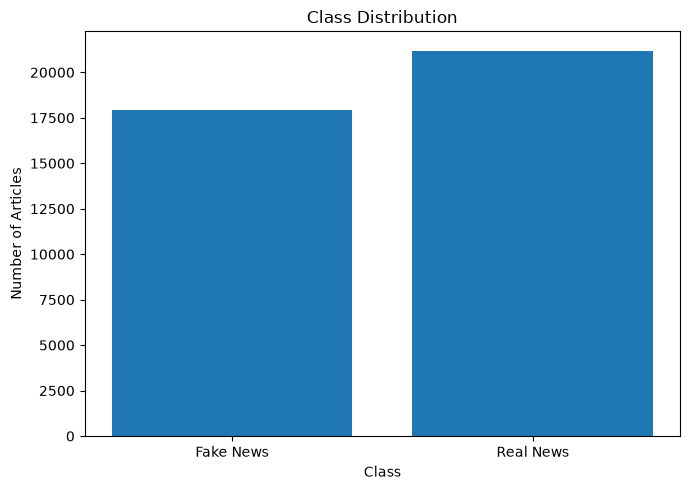

In [15]:
# ============================================================
# PHASE 5.1 — CLASS DISTRIBUTION
# ============================================================

class_counts = news_df["label"].value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Fake News", "Real News"],
    class_counts.values
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()

subject
politicsNews       11211
worldnews           9985
News                9050
politics            4677
left-news           2491
Government News      906
Middle-east          400
US_News              383
Name: count, dtype: int64

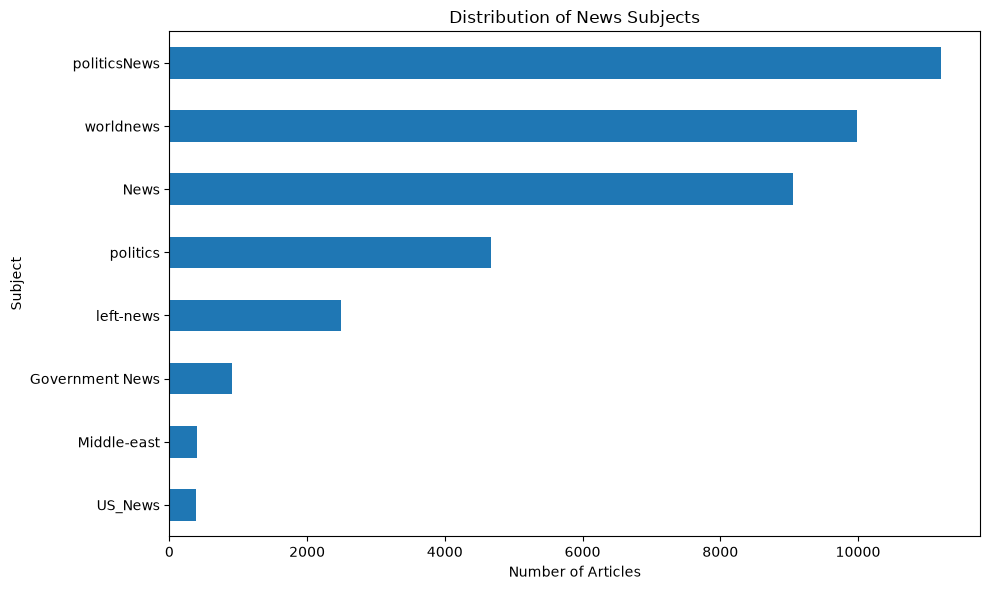

In [16]:
# ============================================================
# PHASE 5.2 — SUBJECT DISTRIBUTION
# ============================================================

subject_counts = news_df["subject"].value_counts()

display(subject_counts)

plt.figure(figsize=(10, 6))

subject_counts.sort_values().plot(
    kind="barh"
)

plt.title("Distribution of News Subjects")
plt.xlabel("Number of Articles")
plt.ylabel("Subject")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# PHASE 5.3 — TEXT STATISTICS
# ============================================================

news_df["word_count"] = news_df["content"].apply(
    lambda x: len(str(x).split())
)

news_df["character_count"] = news_df["content"].apply(
    lambda x: len(str(x))
)

news_df["sentence_count"] = news_df["content"].apply(
    lambda x: max(
        1,
        len(
            re.findall(
                r"[.!?]+",
                str(x)
            )
        )
    )
)

display(
    news_df[
        [
            "word_count",
            "character_count",
            "sentence_count"
        ]
    ].describe()
)

,word_count,character_count,sentence_count
count,39103.000000,39103.000000,39103.000000
mean,410.448968,2504.592282,21.973864
std,315.091516,1943.532917,18.038450
min,2.000000,29.000000,1.000000
25%,220.000000,1347.000000,11.000000
50%,378.000000,2287.000000,19.000000
75%,521.000000,3162.000000,29.000000
max,8148.000000,51892.000000,772.000000


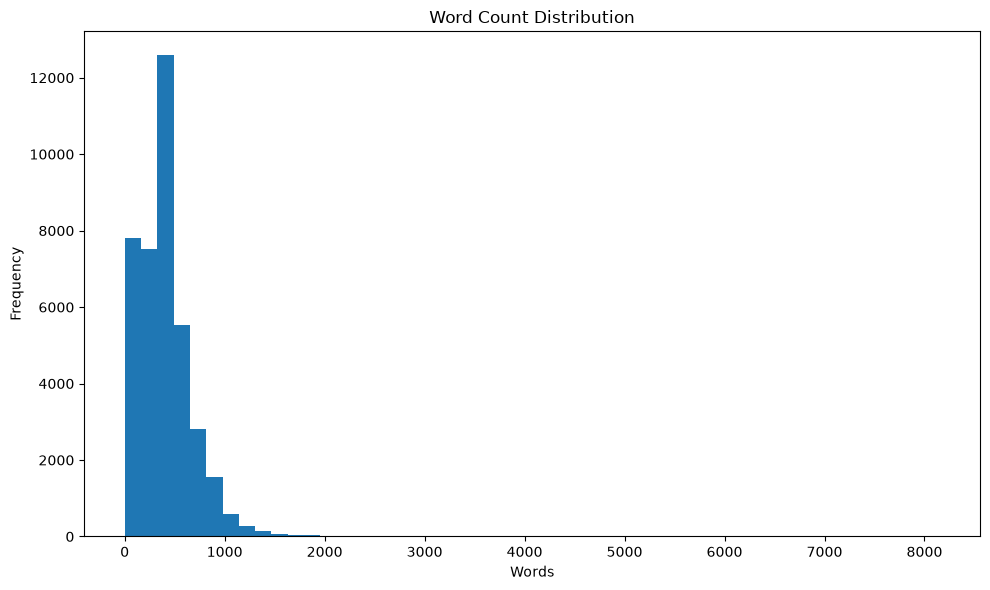

In [18]:
# ============================================================
# PHASE 5.4 — WORD COUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    news_df["word_count"],
    bins=50
)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

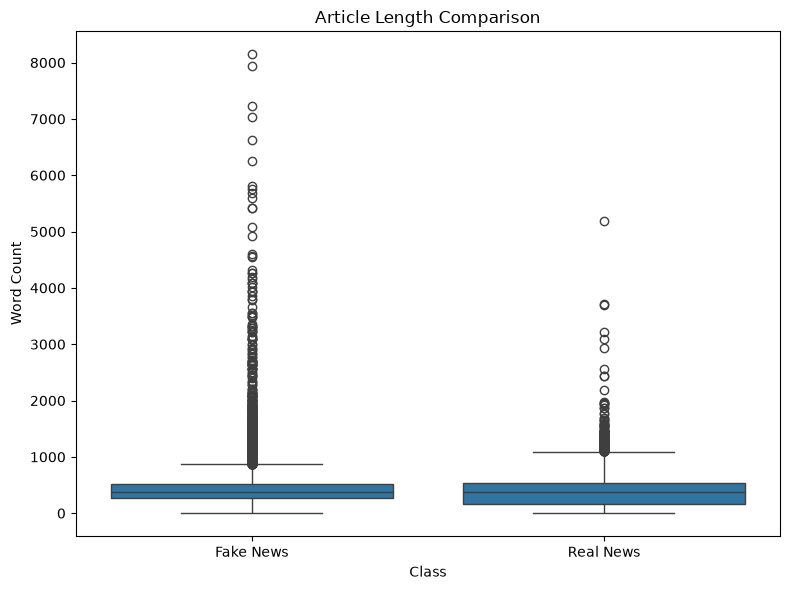

In [19]:
# ============================================================
# PHASE 5.5 — ARTICLE LENGTH BY CLASS
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=news_df,
    x="label",
    y="word_count"
)

plt.xticks(
    [0, 1],
    ["Fake News", "Real News"]
)

plt.title("Article Length Comparison")
plt.xlabel("Class")
plt.ylabel("Word Count")

plt.tight_layout()
plt.show()

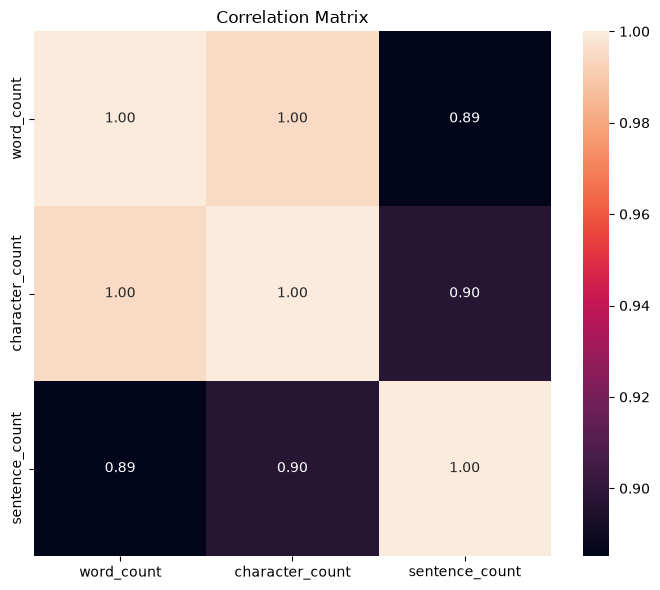

In [20]:
# ============================================================
# PHASE 5.6 — CORRELATION MATRIX
# ============================================================

corr = news_df[
    [
        "word_count",
        "character_count",
        "sentence_count"
    ]
].corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# Phase 6 — Text Preprocessing

## Aim

This phase creates a cleaned textual representation for the traditional machine-learning and BiLSTM models.

The cleaning procedure:

- converts text to lowercase;
- removes URLs;
- removes HTML fragments;
- removes non-alphabetic symbols;
- removes repeated whitespace.

BERT will later use the original combined article content rather than the aggressively cleaned version because contextual Transformer models benefit from retaining natural sentence structure.

In [21]:
# ============================================================
# PHASE 6.1 — TEXT CLEANING FUNCTION
# ============================================================

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Keep alphabetic characters and spaces
    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    # Remove repeated whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


print("Text-cleaning function created.")

Text-cleaning function created.


In [22]:
# ============================================================
# PHASE 6.2 — APPLY CLEANING
# ============================================================

news_df["clean_text"] = news_df["content"].apply(
    clean_text
)

display(
    news_df[
        [
            "content",
            "clean_text"
        ]
    ].head()
)

,content,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls out th circuit court committed...
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon from national securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u s to lift jones act ship...
3,OOPS: Trump Just Accidentally Confirmed He Lea...,oops trump just accidentally confirmed he leak...
4,Donald Trump heads for Scotland to reopen a go...,donald trump heads for scotland to reopen a go...


In [23]:
# ============================================================
# PHASE 6.3 — REMOVE EMPTY CLEANED TEXT
# ============================================================

news_df = news_df[
    news_df["clean_text"].notna()
].copy()

news_df = news_df[
    news_df["clean_text"].str.strip() != ""
].copy()

news_df = news_df.reset_index(drop=True)

print(
    "Dataset after cleaning:",
    news_df.shape
)

Dataset after cleaning: (39098, 10)


# Phase 7 — Final Duplicate Control

## Aim

Different original articles can occasionally become identical after text normalisation.

If identical cleaned texts are allowed to appear in both training and testing data, the evaluation can become artificially optimistic.

For this reason, duplicate removal is performed again using the final `clean_text` representation before the train/test split.

In [24]:
# ============================================================
# PHASE 7.1 — CLEAN-TEXT DUPLICATES
# ============================================================

clean_duplicates = news_df.duplicated(
    subset=["clean_text"]
).sum()

print(
    "Duplicate clean_text rows before removal:",
    clean_duplicates
)

Duplicate clean_text rows before removal: 272


In [25]:
# ============================================================
# PHASE 7.2 — REMOVE CLEAN-TEXT DUPLICATES
# ============================================================

rows_before = len(news_df)

news_df = news_df.drop_duplicates(
    subset=["clean_text"],
    keep="first"
).reset_index(drop=True)

rows_after = len(news_df)

print("=" * 60)
print("FINAL DUPLICATE REMOVAL")
print("=" * 60)

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Removed    :", rows_before - rows_after)

print("=" * 60)

FINAL DUPLICATE REMOVAL
Rows before: 39098
Rows after : 38826
Removed    : 272


In [26]:
# ============================================================
# PHASE 7.3 — FINAL DUPLICATE VERIFICATION
# ============================================================

print(
    "Duplicate clean_text rows:",
    news_df.duplicated(
        subset=["clean_text"]
    ).sum()
)

print(
    "Duplicate original content rows:",
    news_df.duplicated(
        subset=["content"]
    ).sum()
)

Duplicate clean_text rows: 0
Duplicate original content rows: 0


# Phase 8 — Train/Test Split and Integrity Validation

## Aim

All six models must be evaluated using the same held-out test observations.

The final dataset is split using:

- 80% training data;
- 20% test data;
- stratification by class;
- random seed 42.

The split is created once and is not recreated later in the notebook.

In [27]:
# ============================================================
# PHASE 8.1 — COMMON STRATIFIED SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

train_indices, test_indices = train_test_split(
    news_df.index,
    test_size=0.20,
    random_state=SEED,
    stratify=news_df["label"]
)

train_df = news_df.loc[
    train_indices
].reset_index(drop=True)

test_df = news_df.loc[
    test_indices
].reset_index(drop=True)

print("=" * 60)
print("FINAL DATA SPLIT")
print("=" * 60)

print("Full dataset:", len(news_df))
print("Training    :", len(train_df))
print("Testing     :", len(test_df))

print("=" * 60)

FINAL DATA SPLIT
Full dataset: 38826
Training    : 31060
Testing     : 7766


In [28]:
# ============================================================
# PHASE 8.2 — DEFINE MODEL INPUTS
# ============================================================

# Traditional ML / BiLSTM input
X_train = train_df["clean_text"]
X_test = test_df["clean_text"]

# BERT input: minimally processed original text
X_train_bert = train_df["content"]
X_test_bert = test_df["content"]

# Shared labels
y_train = train_df["label"]
y_test = test_df["label"]

print("Traditional/BiLSTM training samples:", len(X_train))
print("Traditional/BiLSTM test samples    :", len(X_test))

print("BERT training samples:", len(X_train_bert))
print("BERT test samples    :", len(X_test_bert))

Traditional/BiLSTM training samples: 31060
Traditional/BiLSTM test samples    : 7766
BERT training samples: 31060
BERT test samples    : 7766


In [29]:
# ============================================================
# PHASE 8.3 — CLASS DISTRIBUTION
# ============================================================

print("Training class distribution:")
print(
    y_train.value_counts().sort_index()
)

print("\nTest class distribution:")
print(
    y_test.value_counts().sort_index()
)

Training class distribution:
label
0    14320
1    16740
Name: count, dtype: int64

Test class distribution:
label
0    3580
1    4186
Name: count, dtype: int64


In [30]:
# ============================================================
# PHASE 8.4 — TRAIN/TEST INTEGRITY CHECK
# ============================================================

train_clean_set = set(
    X_train.astype(str)
)

test_clean_set = set(
    X_test.astype(str)
)

clean_overlap = train_clean_set.intersection(
    test_clean_set
)

train_original_set = set(
    X_train_bert.astype(str)
)

test_original_set = set(
    X_test_bert.astype(str)
)

original_overlap = train_original_set.intersection(
    test_original_set
)

print("=" * 70)
print("DATASET INTEGRITY CHECK")
print("=" * 70)

print(
    "Exact clean-text overlap:",
    len(clean_overlap)
)

print(
    "Exact original-text overlap:",
    len(original_overlap)
)

assert len(clean_overlap) == 0, (
    "Clean-text leakage detected."
)

assert len(original_overlap) == 0, (
    "Original-content leakage detected."
)

print("\n✓ Integrity check passed.")
print("✓ No exact text overlap between training and testing.")

print("=" * 70)

DATASET INTEGRITY CHECK
Exact clean-text overlap: 0
Exact original-text overlap: 0

✓ Integrity check passed.
✓ No exact text overlap between training and testing.


# Phase 9 — TF-IDF Feature Representation

## Aim

The traditional machine-learning classifiers require numerical input.

TF-IDF converts the cleaned text into sparse numerical vectors.

Methodological control:

- the vectoriser is fitted only on the training data;
- the fitted training vocabulary is applied to the test data;
- the test set is never used to learn the vocabulary or IDF statistics.

In [31]:
# ============================================================
# PHASE 9.1 — TF-IDF
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

TFIDF_FEATURES = 10000

tfidf = TfidfVectorizer(
    max_features=TFIDF_FEATURES,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print("=" * 60)
print("TF-IDF FEATURE EXTRACTION")
print("=" * 60)

print(
    "Training Feature Matrix:",
    X_train_tfidf.shape
)

print(
    "Testing Feature Matrix :",
    X_test_tfidf.shape
)

print("=" * 60)

TF-IDF FEATURE EXTRACTION
Training Feature Matrix: (31060, 10000)
Testing Feature Matrix : (7766, 10000)


In [32]:
# ============================================================
# PHASE 9.2 — SAVE TF-IDF VECTORIZER
# ============================================================

with open(
    "saved_models/tfidf.pkl",
    "wb"
) as file:

    pickle.dump(
        tfidf,
        file
    )

print(
    "TF-IDF vectorizer saved successfully."
)

TF-IDF vectorizer saved successfully.


# Phase 10 — Evaluation Framework

All models are evaluated using the same five measures:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

A common evaluation function is used to reduce duplicated code and improve consistency.

In [33]:
# ============================================================
# PHASE 10.1 — EVALUATION FUNCTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)


def evaluate_binary_model(
    name,
    y_true,
    y_pred,
    y_prob
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    print("=" * 70)
    print(name.upper())
    print("=" * 70)

    print(f"Accuracy : {accuracy:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Recall   : {recall:.6f}")
    print(f"F1-score : {f1:.6f}")
    print(f"ROC-AUC  : {auc:.6f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Fake News",
                "Real News"
            ],
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    }


print("Evaluation function created.")

Evaluation function created.


# Phase 11 — Logistic Regression

Logistic Regression is used as a linear baseline for the TF-IDF representation.

The final held-out test set is used only after model fitting.

In [34]:
# ============================================================
# PHASE 11.1 — TRAIN LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print(
    "Logistic Regression trained successfully."
)

Logistic Regression trained successfully.


In [35]:
# ============================================================
# PHASE 11.2 — LOGISTIC REGRESSION PREDICTIONS
# ============================================================

lr_pred = lr_model.predict(
    X_test_tfidf
)

lr_prob = lr_model.predict_proba(
    X_test_tfidf
)[:, 1]

lr_result = evaluate_binary_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

lr_accuracy = lr_result["Accuracy"]
lr_precision = lr_result["Precision"]
lr_recall = lr_result["Recall"]
lr_f1 = lr_result["F1-Score"]
lr_auc = lr_result["ROC-AUC"]

LOGISTIC REGRESSION
Accuracy : 0.985449
Precision: 0.982926
Recall   : 0.990205
F1-score : 0.986552
ROC-AUC  : 0.998756

Classification Report:

              precision    recall  f1-score   support

   Fake News       0.99      0.98      0.98      3580
   Real News       0.98      0.99      0.99      4186

    accuracy                           0.99      7766
   macro avg       0.99      0.99      0.99      7766
weighted avg       0.99      0.99      0.99      7766



In [36]:
# ============================================================
# PHASE 12.1 — MULTINOMIAL NAIVE BAYES
# ============================================================

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(
    X_test_tfidf
)

nb_prob = nb_model.predict_proba(
    X_test_tfidf
)[:, 1]

nb_result = evaluate_binary_model(
    "Naive Bayes",
    y_test,
    nb_pred,
    nb_prob
)

nb_accuracy = nb_result["Accuracy"]
nb_precision = nb_result["Precision"]
nb_recall = nb_result["Recall"]
nb_f1 = nb_result["F1-Score"]
nb_auc = nb_result["ROC-AUC"]

NAIVE BAYES
Accuracy : 0.949910
Precision: 0.953644
Recall   : 0.953416
F1-score : 0.953530
ROC-AUC  : 0.987339

Classification Report:

              precision    recall  f1-score   support

   Fake News       0.95      0.95      0.95      3580
   Real News       0.95      0.95      0.95      4186

    accuracy                           0.95      7766
   macro avg       0.95      0.95      0.95      7766
weighted avg       0.95      0.95      0.95      7766



In [37]:
# ============================================================
# PHASE 13.1 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_pred = rf_model.predict(
    X_test_tfidf
)

rf_prob = rf_model.predict_proba(
    X_test_tfidf
)[:, 1]

rf_result = evaluate_binary_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

rf_accuracy = rf_result["Accuracy"]
rf_precision = rf_result["Precision"]
rf_recall = rf_result["Recall"]
rf_f1 = rf_result["F1-Score"]
rf_auc = rf_result["ROC-AUC"]

RANDOM FOREST
Accuracy : 0.995879
Precision: 0.994759
Recall   : 0.997611
F1-score : 0.996183
ROC-AUC  : 0.999640

Classification Report:

              precision    recall  f1-score   support

   Fake News       1.00      0.99      1.00      3580
   Real News       0.99      1.00      1.00      4186

    accuracy                           1.00      7766
   macro avg       1.00      1.00      1.00      7766
weighted avg       1.00      1.00      1.00      7766



In [38]:
# ============================================================
# PHASE 14.1 — SUPPORT VECTOR MACHINE
# ============================================================

from sklearn.svm import SVC

svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=SEED
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_test_tfidf
)

svm_prob = svm_model.predict_proba(
    X_test_tfidf
)[:, 1]

svm_result = evaluate_binary_model(
    "Support Vector Machine",
    y_test,
    svm_pred,
    svm_prob
)

svm_accuracy = svm_result["Accuracy"]
svm_precision = svm_result["Precision"]
svm_recall = svm_result["Recall"]
svm_f1 = svm_result["F1-Score"]
svm_auc = svm_result["ROC-AUC"]

SUPPORT VECTOR MACHINE
Accuracy : 0.992403
Precision: 0.992130
Recall   : 0.993789
F1-score : 0.992959
ROC-AUC  : 0.999273

Classification Report:

              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99      3580
   Real News       0.99      0.99      0.99      4186

    accuracy                           0.99      7766
   macro avg       0.99      0.99      0.99      7766
weighted avg       0.99      0.99      0.99      7766



# Phase 15 — Cross-Validation of Traditional Models

Cross-validation provides supplementary evidence about model stability.

To avoid feature-extraction leakage, TF-IDF is placed inside each scikit-learn pipeline.

This means that the vectoriser is re-fitted separately inside each training fold.

In [39]:
# ============================================================
# PHASE 15.1 — CROSS-VALIDATION CONFIGURATION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print("Cross-validation strategy created.")

Cross-validation strategy created.


In [40]:
# ============================================================
# PHASE 15.2 — LOGISTIC REGRESSION CV
# ============================================================

lr_cv_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=TFIDF_FEATURES,
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

lr_cv_scores = cross_val_score(
    lr_cv_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("LR CV scores:", lr_cv_scores)
print("LR mean:", lr_cv_scores.mean())
print("LR std :", lr_cv_scores.std())

LR CV scores: [0.98599485 0.98760464 0.98760464 0.98631681 0.98728268]
LR mean: 0.9869607211848036
LR std : 0.0006753437528462136


In [41]:
# ============================================================
# PHASE 15.3 — NAIVE BAYES CV
# ============================================================

nb_cv_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=TFIDF_FEATURES,
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),
    (
        "model",
        MultinomialNB()
    )
])

nb_cv_scores = cross_val_score(
    nb_cv_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("NB CV scores:", nb_cv_scores)
print("NB mean:", nb_cv_scores.mean())
print("NB std :", nb_cv_scores.std())

NB CV scores: [0.9454282  0.94913071 0.95138442 0.95122344 0.9515454 ]
NB mean: 0.9497424339987124
NB std : 0.0023292462649949666


In [42]:
# ============================================================
# PHASE 15.4 — RANDOM FOREST CV
# ============================================================

rf_cv_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=TFIDF_FEATURES,
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=SEED,
            n_jobs=1
        )
    )
])

rf_cv_scores = cross_val_score(
    rf_cv_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("RF CV scores:", rf_cv_scores)
print("RF mean:", rf_cv_scores.mean())
print("RF std :", rf_cv_scores.std())

RF CV scores: [0.99678042 0.9969414  0.99790728 0.99597553 0.99726336]
RF mean: 0.996973599484868
RF std : 0.0006309052782441874


In [43]:
# ============================================================
# PHASE 15.5 — SVM CV
# ============================================================

svm_cv_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=TFIDF_FEATURES,
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),
    (
        "model",
        SVC(
            kernel="linear",
            probability=False
        )
    )
])

svm_cv_scores = cross_val_score(
    svm_cv_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)

print("SVM CV scores:", svm_cv_scores)
print("SVM mean:", svm_cv_scores.mean())
print("SVM std :", svm_cv_scores.std())

SVM CV scores: [0.99323889 0.99291693 0.99517064 0.9916291  0.99388281]
SVM mean: 0.9933676754668384
SVM std : 0.001162618807808635


In [44]:
# ============================================================
# PHASE 15.6 — CV SUMMARY
# ============================================================

cv_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Mean CV Accuracy": [
        lr_cv_scores.mean(),
        nb_cv_scores.mean(),
        rf_cv_scores.mean(),
        svm_cv_scores.mean()
    ],
    "CV Std Dev": [
        lr_cv_scores.std(),
        nb_cv_scores.std(),
        rf_cv_scores.std(),
        svm_cv_scores.std()
    ]
})

cv_summary = cv_summary.sort_values(
    "Mean CV Accuracy",
    ascending=False
).reset_index(drop=True)

display(cv_summary)

cv_summary.to_csv(
    "results/cross_validation_summary.csv",
    index=False
)

,Model,Mean CV Accuracy,CV Std Dev
0,Random Forest,0.996974,0.000631
1,Support Vector Machine,0.993368,0.001163
2,Logistic Regression,0.986961,0.000675
3,Naive Bayes,0.949742,0.002329


# Phase 16 — Bidirectional LSTM

## Aim

BiLSTM provides the recurrent deep-learning component of the experiment.

Unlike TF-IDF models, the network receives ordered token sequences.

The tokenizer is fitted only on the training set to prevent test information from entering the learned vocabulary.

In [45]:
# ============================================================
# PHASE 16.1 — IMPORT TENSORFLOW
# ============================================================

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [46]:
# ============================================================
# PHASE 16.2 — BILSTM TOKENISATION
# ============================================================

BILSTM_MAX_WORDS = 20000
BILSTM_MAX_LENGTH = 300

bilstm_tokenizer = Tokenizer(
    num_words=BILSTM_MAX_WORDS,
    oov_token="<OOV>"
)

# IMPORTANT:
# vocabulary learned only from training data
bilstm_tokenizer.fit_on_texts(
    X_train
)

X_train_seq = bilstm_tokenizer.texts_to_sequences(
    X_train
)

X_test_seq = bilstm_tokenizer.texts_to_sequences(
    X_test
)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=BILSTM_MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=BILSTM_MAX_LENGTH,
    padding="post",
    truncating="post"
)

print(
    "Training shape:",
    X_train_pad.shape
)

print(
    "Test shape:",
    X_test_pad.shape
)

Training shape: (31060, 300)
Test shape: (7766, 300)


In [47]:
# ============================================================
# PHASE 16.3 — SAVE BILSTM TOKENIZER
# ============================================================

with open(
    "saved_models/bilstm_tokenizer.pkl",
    "wb"
) as file:

    pickle.dump(
        bilstm_tokenizer,
        file
    )

print("BiLSTM tokenizer saved.")

BiLSTM tokenizer saved.


In [48]:
# ============================================================
# PHASE 16.4 — BUILD BILSTM
# ============================================================

EMBEDDING_DIM = 100

bilstm_model = Sequential([
    Embedding(
        input_dim=BILSTM_MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=BILSTM_MAX_LENGTH
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=False
        )
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
# ============================================================
# PHASE 16.5 — CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "saved_models/bilstm_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [50]:
# ============================================================
# PHASE 16.6 — TRAIN BILSTM
# ============================================================

BILSTM_EPOCHS = 10
BILSTM_BATCH_SIZE = 32

history = bilstm_model.fit(
    X_train_pad,
    y_train,
    epochs=BILSTM_EPOCHS,
    batch_size=BILSTM_BATCH_SIZE,
    validation_split=0.20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9852 - loss: 0.0400
Epoch 1: val_accuracy improved from None to 0.99920, saving model to saved_models/bilstm_best.keras

Epoch 1: finished saving model to saved_models/bilstm_best.keras
777/777 ━━━━━━━━━━━━━━━━━━━━ 137s 172ms/step - accuracy: 0.9852 - loss: 0.0400 - val_accuracy: 0.9992 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 2/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9962 - loss: 0.0153
Epoch 2: val_accuracy did not improve from 0.99920
777/777 ━━━━━━━━━━━━━━━━━━━━ 136s 174ms/step - accuracy: 0.9962 - loss: 0.0153 - val_accuracy: 0.9990 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 3/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9996 - loss: 0.0017
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.99920
777/777 ━━━━━━━━━━━━━━━━━━━━ 140s 181ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9989

In [51]:
# ============================================================
# PHASE 16.7 — BILSTM EVALUATION
# ============================================================

bilstm_prob = bilstm_model.predict(
    X_test_pad
).ravel()

bilstm_pred = (
    bilstm_prob >= 0.5
).astype(int)

bilstm_result = evaluate_binary_model(
    "BiLSTM",
    y_test,
    bilstm_pred,
    bilstm_prob
)

bilstm_accuracy = bilstm_result["Accuracy"]
bilstm_precision = bilstm_result["Precision"]
bilstm_recall = bilstm_result["Recall"]
bilstm_f1 = bilstm_result["F1-Score"]
bilstm_auc = bilstm_result["ROC-AUC"]

243/243 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step
BILSTM
Accuracy : 0.998069
Precision: 0.999282
Recall   : 0.997133
F1-score : 0.998206
ROC-AUC  : 0.999859

Classification Report:

              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      3580
   Real News       1.00      1.00      1.00      4186

    accuracy                           1.00      7766
   macro avg       1.00      1.00      1.00      7766
weighted avg       1.00      1.00      1.00      7766



In [52]:
# ============================================================
# PHASE 16.8 — SAVE FINAL BILSTM
# ============================================================

bilstm_model.save(
    "saved_models/bilstm_final.keras"
)

print("Final BiLSTM model saved.")

243/243 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step
BILSTM
Accuracy : 0.998069
Precision: 0.999282
Recall   : 0.997133
F1-score : 0.998206
ROC-AUC  : 0.999859

Classification Report:

              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      3580
   Real News       1.00      1.00      1.00      4186

    accuracy                           1.00      7766
   macro avg       1.00      1.00      1.00      7766
weighted avg       1.00      1.00      1.00      7766



# Phase 17 — BERT Data Preparation

## Aim

The BERT model uses the same training and testing article rows as the other five models.

Unlike the traditional models, BERT receives the original combined title and article text rather than the aggressively cleaned representation.

A further validation subset is created from the training data.

The final test set remains untouched until final model evaluation.

In [53]:
# ============================================================
# PHASE 17.1 — CREATE BERT TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

(
    X_bert_train,
    X_bert_val,
    y_bert_train,
    y_bert_val
) = train_test_split(
    X_train_bert,
    y_train,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train
)

print("=" * 60)
print("BERT DATA SPLIT")
print("=" * 60)

print(
    "BERT training:",
    len(X_bert_train)
)

print(
    "BERT validation:",
    len(X_bert_val)
)

print(
    "BERT final test:",
    len(X_test_bert)
)

print("=" * 60)

BERT DATA SPLIT
BERT training: 27954
BERT validation: 3106
BERT final test: 7766


In [54]:
# ============================================================
# PHASE 18.1 — IMPORT TRANSFORMERS
# ============================================================

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from torch.utils.data import Dataset

from scipy.special import softmax

BERT_MODEL_NAME = "bert-base-uncased"
BERT_MAX_LENGTH = 256

bert_tokenizer = AutoTokenizer.from_pretrained(
    BERT_MODEL_NAME
)

print("BERT tokenizer loaded.")

BERT tokenizer loaded.


In [55]:
# ============================================================
# PHASE 18.2 — TOKENISE DATA
# ============================================================

train_encodings = bert_tokenizer(
    X_bert_train.astype(str).tolist(),
    truncation=True,
    padding=True,
    max_length=BERT_MAX_LENGTH
)

val_encodings = bert_tokenizer(
    X_bert_val.astype(str).tolist(),
    truncation=True,
    padding=True,
    max_length=BERT_MAX_LENGTH
)

test_encodings = bert_tokenizer(
    X_test_bert.astype(str).tolist(),
    truncation=True,
    padding=True,
    max_length=BERT_MAX_LENGTH
)

print("BERT tokenisation completed.")

BERT tokenisation completed.


In [56]:
# ============================================================
# PHASE 18.3 — PYTORCH DATASET
# ============================================================

class FakeNewsDataset(Dataset):

    def __init__(
        self,
        encodings,
        labels
    ):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(
        self,
        idx
    ):

        item = {
            key: torch.tensor(
                value[idx]
            )
            for key, value
            in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            int(self.labels[idx]),
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)


train_dataset = FakeNewsDataset(
    train_encodings,
    y_bert_train
)

val_dataset = FakeNewsDataset(
    val_encodings,
    y_bert_val
)

test_dataset = FakeNewsDataset(
    test_encodings,
    y_test
)

print("BERT datasets created.")

BERT datasets created.


# Phase 19 — BERT Fine-Tuning

The pretrained `bert-base-uncased` model is fine-tuned for binary classification.

Configuration:

- Classes: 2
- Maximum length: 256
- Epochs: 3
- Training batch size: 8
- Evaluation batch size: 8
- Learning rate: 2e-5
- Weight decay: 0.01
- Best checkpoint selected using validation F1-score

The final test set is not used for checkpoint selection.

In [57]:
# ============================================================
# PHASE 19.1 — LOAD BERT MODEL
# ============================================================

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=2
)

bert_model.to(device)

print("BERT model loaded.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3049.71it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

BERT model loaded.


In [58]:
# ============================================================
# PHASE 19.2 — METRIC FUNCTION
# ============================================================

def compute_bert_metrics(eval_pred):

    logits, labels = eval_pred

    probabilities = softmax(
        logits,
        axis=1
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    positive_prob = probabilities[:, 1]

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            labels,
            positive_prob
        )
    }

In [59]:
# ============================================================
# PHASE 19.3 — TRAINING ARGUMENTS
# ============================================================

training_args = TrainingArguments(
    output_dir="saved_models/bert_checkpoints",

    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="epoch",

    save_total_limit=2,

    seed=SEED,

    report_to="none"
)

In [60]:
# ============================================================
# PHASE 19.4 — CREATE TRAINER
# ============================================================

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_bert_metrics,
    processing_class=bert_tokenizer
)

print("BERT Trainer created.")

BERT Trainer created.


In [61]:
# ============================================================
# PHASE 19.5 — TRAIN BERT
# ============================================================

train_result = trainer.train()

print("BERT fine-tuning completed.")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.013957,0.001630,0.999678,1.000000,0.999403,0.999701,1.000000
2,0.002971,0.007235,0.999034,0.998806,0.999403,0.999104,0.999998
3,0.000283,0.005479,0.999356,0.999403,0.999403,0.999403,0.999999


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

BERT fine-tuning completed.


In [62]:
# ============================================================
# PHASE 20.1 — SAVE FINAL BERT MODEL
# ============================================================

FINAL_BERT_DIR = "saved_models/final_bert"

os.makedirs(
    FINAL_BERT_DIR,
    exist_ok=True
)

trainer.save_model(
    FINAL_BERT_DIR
)

bert_tokenizer.save_pretrained(
    FINAL_BERT_DIR
)

print(
    "Final BERT model saved to:",
    FINAL_BERT_DIR
)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.68it/s]

Final BERT model saved to: saved_models/final_bert


# Phase 21 — Final BERT Evaluation

The best validation-selected BERT checkpoint is evaluated once on the held-out final test set.

The following outputs are generated:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Classification report
- Confusion matrix
- ROC curve

In [63]:
# ============================================================
# PHASE 21.1 — FINAL TEST PREDICTIONS
# ============================================================

bert_test_output = trainer.predict(
    test_dataset
)

bert_logits = bert_test_output.predictions
y_true = bert_test_output.label_ids

bert_probabilities = softmax(
    bert_logits,
    axis=1
)

y_prob = bert_probabilities[:, 1]

y_pred = np.argmax(
    bert_probabilities,
    axis=1
)

print(
    "BERT test predictions completed."
)

BERT test predictions completed.


In [64]:
# ============================================================
# PHASE 21.2 — BERT METRICS
# ============================================================

bert_result = evaluate_binary_model(
    "BERT",
    y_true,
    y_pred,
    y_prob
)

bert_accuracy = bert_result["Accuracy"]
bert_precision = bert_result["Precision"]
bert_recall = bert_result["Recall"]
bert_f1 = bert_result["F1-Score"]
bert_auc = bert_result["ROC-AUC"]

BERT
Accuracy : 0.999227
Precision: 1.000000
Recall   : 0.998567
F1-score : 0.999283
ROC-AUC  : 0.999992

Classification Report:

              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      3580
   Real News       1.00      1.00      1.00      4186

    accuracy                           1.00      7766
   macro avg       1.00      1.00      1.00      7766
weighted avg       1.00      1.00      1.00      7766



BERT Confusion Matrix:
[[3580    0]
 [   6 4180]]


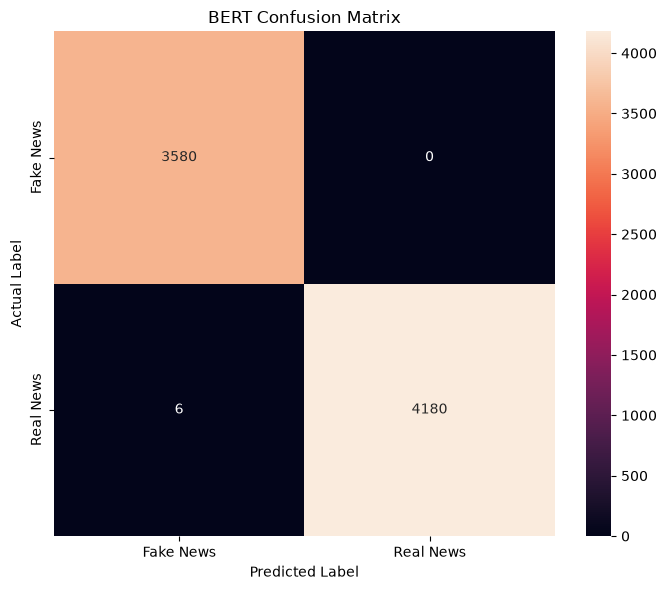

In [65]:
# ============================================================
# PHASE 22.1 — BERT CONFUSION MATRIX
# ============================================================

cm_bert = confusion_matrix(
    y_true,
    y_pred
)

print("BERT Confusion Matrix:")
print(cm_bert)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    xticklabels=[
        "Fake News",
        "Real News"
    ],
    yticklabels=[
        "Fake News",
        "Real News"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("BERT Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "figures/bert_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

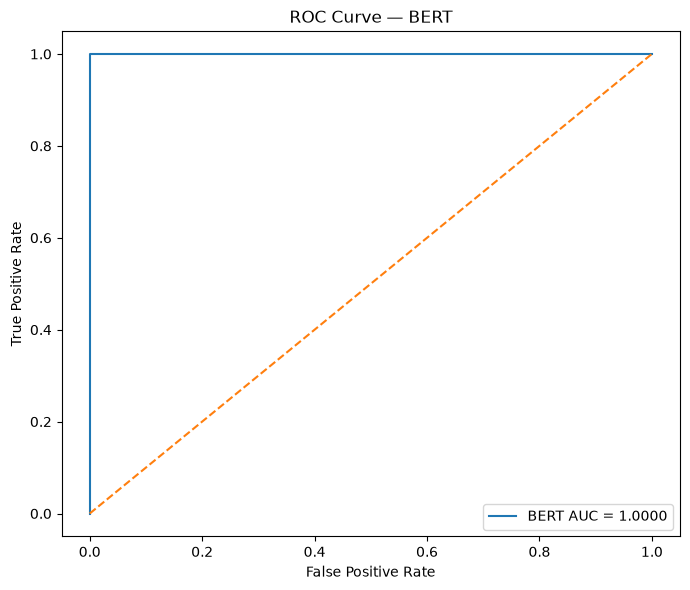

In [66]:
# ============================================================
# PHASE 23.1 — BERT ROC CURVE
# ============================================================

bert_fpr, bert_tpr, _ = roc_curve(
    y_true,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    bert_fpr,
    bert_tpr,
    label=f"BERT AUC = {bert_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — BERT")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/bert_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Phase 24 — Comparative Model Evaluation

All six models are compared using metrics produced directly from the current corrected run.

The table is generated from variables rather than manually typing performance values. This reduces transcription errors and improves reproducibility.

In [67]:
# ============================================================
# PHASE 24.1 — FINAL COMPARISON TABLE
# ============================================================

final_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Support Vector Machine",
        "BiLSTM",
        "BERT"
    ],

    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy,
        svm_accuracy,
        bilstm_accuracy,
        bert_accuracy
    ],

    "Precision": [
        lr_precision,
        nb_precision,
        rf_precision,
        svm_precision,
        bilstm_precision,
        bert_precision
    ],

    "Recall": [
        lr_recall,
        nb_recall,
        rf_recall,
        svm_recall,
        bilstm_recall,
        bert_recall
    ],

    "F1-Score": [
        lr_f1,
        nb_f1,
        rf_f1,
        svm_f1,
        bilstm_f1,
        bert_f1
    ],

    "ROC-AUC": [
        lr_auc,
        nb_auc,
        rf_auc,
        svm_auc,
        bilstm_auc,
        bert_auc
    ]
})

display(
    final_comparison.round(6)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.985449,0.982926,0.990205,0.986552,0.998756
1,Naive Bayes,0.949910,0.953644,0.953416,0.953530,0.987339
2,Random Forest,0.995879,0.994759,0.997611,0.996183,0.999640
3,Support Vector Machine,0.992403,0.992130,0.993789,0.992959,0.999273
4,BiLSTM,0.998069,0.999282,0.997133,0.998206,0.999859
5,BERT,0.999227,1.000000,0.998567,0.999283,0.999992


In [68]:
# ============================================================
# PHASE 24.2 — SAVE FINAL COMPARISON
# ============================================================

final_comparison.to_csv(
    "results/final_model_comparison.csv",
    index=False
)

print(
    "Final model comparison saved."
)

Final model comparison saved.


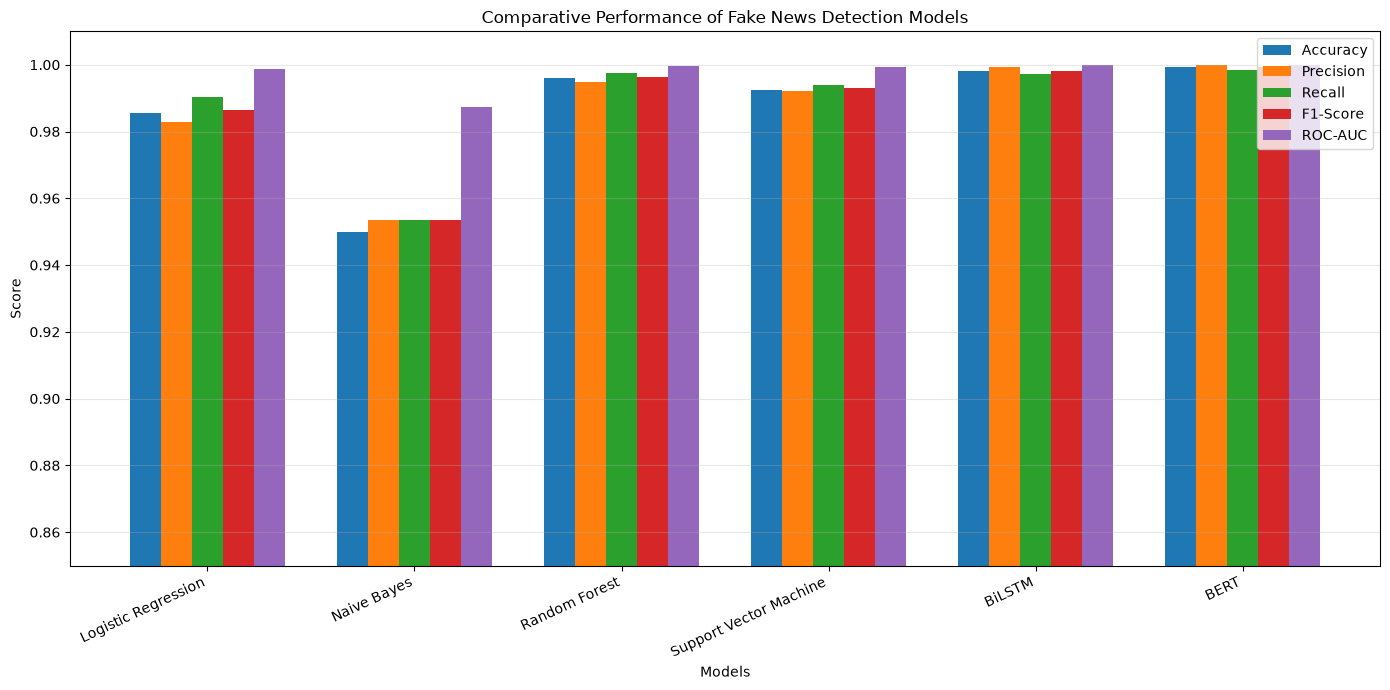

In [69]:
# ============================================================
# PHASE 25.1 — MODEL COMPARISON FIGURE
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

models = final_comparison[
    "Model"
].tolist()

x = np.arange(
    len(models)
)

width = 0.15

plt.figure(
    figsize=(14, 7)
)

for i, metric in enumerate(metrics):

    values = final_comparison[
        metric
    ].values

    plt.bar(
        x + (i - 2) * width,
        values,
        width,
        label=metric
    )

plt.xlabel("Models")
plt.ylabel("Score")

plt.title(
    "Comparative Performance of Fake News Detection Models"
)

plt.xticks(
    x,
    models,
    rotation=25,
    ha="right"
)

plt.ylim(
    0.85,
    1.01
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
# ============================================================
# PHASE 26.1 — MODEL RANKING
# ============================================================

ranked_models = final_comparison.sort_values(
    by=[
        "F1-Score",
        "Accuracy",
        "ROC-AUC"
    ],
    ascending=False
).reset_index(drop=True)

display(
    ranked_models.round(6)
)

best_model_name = ranked_models.loc[
    0,
    "Model"
]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Selected model:",
    best_model_name
)

print("=" * 70)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,BERT,0.999227,1.000000,0.998567,0.999283,0.999992
1,BiLSTM,0.998069,0.999282,0.997133,0.998206,0.999859
2,Random Forest,0.995879,0.994759,0.997611,0.996183,0.999640
3,Support Vector Machine,0.992403,0.992130,0.993789,0.992959,0.999273
4,Logistic Regression,0.985449,0.982926,0.990205,0.986552,0.998756
5,Naive Bayes,0.949910,0.953644,0.953416,0.953530,0.987339


BEST MODEL
Selected model: BERT


# Phase 27 — Load Final Saved BERT

The explainability stage uses the final saved model rather than retraining BERT.

This reproduces the same deployment logic used by the Streamlit application.

In [72]:
# ============================================================
# PHASE 27.1 — LOAD FINAL MODEL
# ============================================================

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

bert_tokenizer = AutoTokenizer.from_pretrained(
    FINAL_BERT_DIR
)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    FINAL_BERT_DIR
)

bert_model.to(device)
bert_model.eval()

print(
    "Saved final BERT model loaded successfully."
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2588.17it/s]


Saved final BERT model loaded successfully.


In [77]:
# ============================================================
# PHASE 28.1 — MEMORY-SAFE BERT PREDICTION FUNCTION
# ============================================================

import numpy as np
import torch

def bert_predict_proba(texts, batch_size=8):

    # Convert single string to list
    if isinstance(texts, str):
        texts = [texts]

    # Ensure valid strings
    texts = [
        str(text) if str(text).strip() else " "
        for text in texts
    ]

    all_probabilities = []

    # Process LIME/SHAP samples in small batches
    for start in range(0, len(texts), batch_size):

        batch_texts = texts[
            start:start + batch_size
        ]

        encoding = bert_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=BERT_MAX_LENGTH,
            return_tensors="pt"
        )

        encoding = {
            key: value.to(device)
            for key, value in encoding.items()
        }

        with torch.no_grad():

            outputs = bert_model(
                **encoding
            )

            probabilities = torch.softmax(
                outputs.logits,
                dim=1
            )

        all_probabilities.append(
            probabilities.cpu().numpy()
        )

        # Release temporary GPU tensors
        del encoding
        del outputs
        del probabilities

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return np.vstack(all_probabilities)


print("Memory-safe BERT prediction function ready.")

Memory-safe BERT prediction function ready.


# Phase 29 — LIME Explainability

LIME is applied to the final BERT classifier to identify words that influence an individual prediction.

The explanation describes local model behaviour.

It should not be interpreted as independent evidence that a news article is objectively true or false.

In [78]:
test_probs = bert_predict_proba([
    "This is a test news article.",
    "Another example article."
])

print(test_probs)
print(test_probs.shape)

[[0.9189847  0.08101535]
 [0.8387733  0.16122669]]
(2, 2)


In [79]:
# ============================================================
# PHASE 29.1 — LIME EXPLANATION
# ============================================================

from lime.lime_text import LimeTextExplainer

CLASS_NAMES = [
    "Fake News",
    "Real News"
]

lime_explainer = LimeTextExplainer(
    class_names=CLASS_NAMES
)

sample_text = X_test_bert.iloc[0]

lime_explanation = lime_explainer.explain_instance(
    sample_text,
    bert_predict_proba,
    num_features=12,
    num_samples=300
)

print("LIME Explanation:")

for feature, weight in lime_explanation.as_list():

    print(
        feature,
        round(weight, 6)
    )

LIME Explanation:
s -6.8e-05
t -1.3e-05
last -5e-06
same -5e-06
still -4e-06
https 3e-06
attacked -3e-06
Labye -2e-06
Of -2e-06
progressives 1e-06
carnival 1e-06
seekers 0.0


# Phase 30 — SHAP Explainability

SHAP provides token-level feature attribution for the final BERT prediction.

As with LIME, SHAP explains behaviour of the trained classifier rather than performing external fact verification.

In [80]:
# ============================================================
# PHASE 30.1 — SHAP EXPLAINER
# ============================================================

import shap

text_masker = shap.maskers.Text(
    bert_tokenizer
)

shap_explainer = shap.Explainer(
    bert_predict_proba,
    text_masker,
    algorithm="partition"
)

print(
    "SHAP explainer created."
)

SHAP explainer created.


In [81]:
# ============================================================
# PHASE 30.2 — GENERATE SHAP EXPLANATION
# ============================================================

shap_sample_text = X_test_bert.iloc[0]

shap_values = shap_explainer(
    [shap_sample_text],
    max_evals=500
)

print(
    "SHAP explanation generated."
)

PartitionExplainer explainer: 2it [00:27, 27.08s/it]               

SHAP explanation generated.


In [82]:
# ============================================================
# PHASE 30.3 — DISPLAY SHAP TEXT EXPLANATION
# ============================================================

shap.plots.text(
    shap_values[0]
)

# Phase 31 — Reproducibility Summary

This phase records the final configuration used in the experiment.

The purpose is to provide a concise audit trail that can be referenced when writing the methodology and defending the project during the viva.

In [83]:
# ============================================================
# PHASE 31.1 — FINAL CONFIGURATION SUMMARY
# ============================================================

experiment_summary = {

    "Random seed": SEED,

    "Final dataset size": len(news_df),

    "Training samples": len(train_df),

    "Testing samples": len(test_df),

    "Clean-text train/test overlap":
        len(clean_overlap),

    "Original-text train/test overlap":
        len(original_overlap),

    "TF-IDF features":
        TFIDF_FEATURES,

    "BiLSTM vocabulary":
        BILSTM_MAX_WORDS,

    "BiLSTM max length":
        BILSTM_MAX_LENGTH,

    "BERT model":
        BERT_MODEL_NAME,

    "BERT max length":
        BERT_MAX_LENGTH,

    "BERT epochs":
        3,

    "BERT batch size":
        8,

    "BERT learning rate":
        2e-5,

    "BERT weight decay":
        0.01
}

experiment_summary_df = pd.DataFrame(
    experiment_summary.items(),
    columns=[
        "Parameter",
        "Value"
    ]
)

display(
    experiment_summary_df
)

experiment_summary_df.to_csv(
    "results/experiment_configuration.csv",
    index=False
)

,Parameter,Value
0,Random seed,42
1,Final dataset size,38826
2,Training samples,31060
3,Testing samples,7766
4,Clean-text train/test overlap,0
5,Original-text train/test overlap,0
6,TF-IDF features,10000
7,BiLSTM vocabulary,20000
8,BiLSTM max length,300
9,BERT model,bert-base-uncased


In [84]:
# ============================================================
# PHASE 32.1 — FINAL VALIDATION
# ============================================================

print("=" * 75)
print("FINAL NOTEBOOK VALIDATION")
print("=" * 75)

print(
    "Dataset size:",
    len(news_df)
)

print(
    "Training size:",
    len(train_df)
)

print(
    "Testing size:",
    len(test_df)
)

print(
    "Clean-text overlap:",
    len(clean_overlap)
)

print(
    "Original-text overlap:",
    len(original_overlap)
)

print(
    "Models compared:",
    len(final_comparison)
)

print(
    "Best model:",
    best_model_name
)

assert len(clean_overlap) == 0
assert len(original_overlap) == 0
assert len(final_comparison) == 6

print("\n✓ Dataset integrity confirmed.")
print("✓ Six-model comparison confirmed.")
print("✓ Final experiment completed successfully.")

print("=" * 75)

FINAL NOTEBOOK VALIDATION
Dataset size: 38826
Training size: 31060
Testing size: 7766
Clean-text overlap: 0
Original-text overlap: 0
Models compared: 6
Best model: BERT

✓ Dataset integrity confirmed.
✓ Six-model comparison confirmed.
✓ Final experiment completed successfully.
